# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Соснило Богдан'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 12     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Соснило Богдан, ШІ-34, варіант 12
ваш потік:                   P>100
ваша пара для графіка 3:     густина вітру та потік P>1
ваш агрегат для етапу 4:     максимум
ваше додаткове питання:      Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
# ВАШ КОД
df = pd.read_excel("iad_excel.xlsx")
display(df.head())
print(df.dtypes)

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                                     object
Unnamed: 1

 "**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*: звичайне читання дало такий результат, тому що воно сприйняло наш документ як таблицю, в яких стовпці це 1 рядок файлу, проте так не є
 

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: 
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
df = pd.read_excel("iad_excel.xlsx",header = None)
display(df.shape)
print(df.head(30))

(7226, 32)

    0                                                  1    2    3     4         5        6      7      8      9       10      11      12     13     14  15  \
0  NaN        ftp://ftp.swpc.noaa.gov/pub/lists/particle/  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
1  NaN                                                NaN  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
2  NaN                :Data_list: 20170901_Gs_part_5m.txt  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
3  NaN                     :Created: 2017 Sep 02 0011 UTC  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
4  NaN  # Prepared by the U.S. Dept. of Commerce, NOAA...  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
5  NaN  # Please send comments and suggestions

### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
RAW = pd.read_excel('iad_excel.xlsx',header = None)

print(RAW.notna().sum())

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7199
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** *3 таблиці, з 1 по 14 стовпець, з 16 по 19, з 24 по 31*

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
print(RAW.iloc[0:25,1].values,"\n")
print(RAW.iloc[0:25,16].values,"\n")
print(RAW.iloc[0:25,26].values)

['ftp://ftp.swpc.noaa.gov/pub/lists/particle/' nan
 ':Data_list: 20170901_Gs_part_5m.txt' ':Created: 2017 Sep 02 0011 UTC'
 '# Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center'
 '# Please send comments and suggestions to SWPC.Webmaster@noaa.gov ' '# '
 '# Label: P > 1 = Particles at >1 Mev'
 '# Label: P > 5 = Particles at >5 Mev'
 '# Label: P >10 = Particles at >10 Mev'
 '# Label: P >30 = Particles at >30 Mev'
 '# Label: P >50 = Particles at >50 Mev'
 '# Label: P>100 = Particles at >100 Mev'
 '# Label: E>0.8 = Electrons at >0.8 Mev'
 '# Label: E>2.0 = Electrons at >2.0 Mev'
 '# Label: E>4.0 = Electrons at >4.0 Mev'
 '# Units: Particles = Protons/cm2-s-sr'
 '# Units: Electrons = Electrons/cm2-s-sr' '# Source: GOES-15'
 '# Location: W135' '# Missing data: -1.00e+05' nan
 '5-minute  GOES-15 Solar Particle and Electron Flux' nan '# UT'] 

[nan nan nan nan nan nan nan nan nan nan nan nan nan
 'ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt' nan
 

### **Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
| A | GOES-15 |Protons/cm2-s-sr, Electrons/cm2-s-sr |
| B | Daily Solar Data |не вказано  |
| C | Solar Wind Parameters for Carrington Rotation |Proton speed [km/sec],Proton density [protons per cubic centimeter]  |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
A = RAW.iloc[26:, 1:15].copy()
A.columns = ['YR', 'MO', 'DA', 'HHMM', 'Julian', 'Sec', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']
A = A.apply(pd.to_numeric, errors='coerce')

B = RAW.iloc[27:53, 16:20].copy()
B.columns = ['YR', 'MO', 'DA', 'Radio Flux 10.7']
B = B.apply(pd.to_numeric, errors='coerce')

C = RAW.iloc[27:628, 24:33].copy()
C.columns = ['idx1', 'idx2', 'YR', 'MO', 'DA', 'HH', 'SPEED', 'DENSITY']
C = C.apply(pd.to_numeric, errors='coerce')

### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
A = A.dropna(subset=['YR', 'MO', 'DA', 'HHMM'])
B = B.dropna(subset=['YR', 'MO', 'DA'])
C = C.dropna(subset=['YR', 'MO', 'DA', 'HH'])


A['HHMM_str'] = A['HHMM'].astype(int).astype(str).str.zfill(4)

A['ts'] = pd.to_datetime(A['YR'].astype(int).astype(str) + '-' + A['MO'].astype(int).astype(str) + '-' + A['DA'].astype(int).astype(str) + ' ' + A['HHMM_str'], format='%Y-%m-%d %H%M')

B['ts'] = pd.to_datetime(B['YR'].astype(int).astype(str) + '-' + B['MO'].astype(int).astype(str) + '-' + B['DA'].astype(int).astype(str), format='%Y-%m-%d')

C['ts'] = pd.to_datetime('20' + C['YR'].astype(int).astype(str) + '-' + C['MO'].astype(int).astype(str) + '-' + C['DA'].astype(int).astype(str) + ' ' + C['HH'].astype(int).astype(str), format='%Y-%m-%d %H')

print("Межі A:", A['ts'].min(), "—", A['ts'].max())
print("Межі B:", B['ts'].min(), "—", B['ts'].max())
print("Межі C:", C['ts'].min(), "—", C['ts'].max())

Межі A: 2017-08-28 00:00:00 — 2017-09-21 23:55:00
Межі B: 2017-08-28 00:00:00 — 2017-09-21 00:00:00
Межі C: 2017-08-28 00:00:00 — 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
for name, df in zip(['A', 'B', 'C'], [A, B, C]):
    print(f"Таблиця {name}")
    print("Розмір:", df.shape)
    print("Дублікати:", df.duplicated().sum())

    print("\nКількість пропусків (NaN) по стовпцях:")
    print(df.isna().sum())
    print("типи:", df.dtypes)
    display(df.describe())

Таблиця A
Розмір: (7200, 16)
Дублікати: 0

Кількість пропусків (NaN) по стовпцях:
YR          0
MO          0
DA          0
HHMM        0
Julian      0
Sec         0
P>1         3
P>5         3
P>10        3
P>30        3
P>50        3
P>100       3
E>0.8       3
E>2.0       3
HHMM_str    0
ts          0
dtype: int64
типи: YR                   int64
MO                   int64
DA                   int64
HHMM                 int64
Julian               int64
Sec                  int64
P>1                float64
P>5                float64
P>10               float64
P>30               float64
P>50               float64
P>100              float64
E>0.8              float64
E>2.0              float64
HHMM_str            object
ts          datetime64[ns]
dtype: object


,YR,MO,DA,HHMM,Julian,Sec,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN


Таблиця B
Розмір: (25, 5)
Дублікати: 0

Кількість пропусків (NaN) по стовпцях:
YR                 0
MO                 0
DA                 0
Radio Flux 10.7    0
ts                 0
dtype: int64
типи: YR                        float64
MO                        float64
DA                        float64
Radio Flux 10.7           float64
ts                 datetime64[ns]
dtype: object


,YR,MO,DA,Radio Flux 10.7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN


Таблиця C
Розмір: (601, 9)
Дублікати: 0

Кількість пропусків (NaN) по стовпцях:
idx1       0
idx2       0
YR         0
MO         0
DA         0
HH         0
SPEED      0
DENSITY    0
ts         0
dtype: int64
типи: idx1              float64
idx2              float64
YR                  int64
MO                  int64
DA                  int64
HH                  int64
SPEED               int64
DENSITY           float64
ts         datetime64[ns]
dtype: object


,idx1,idx2,YR,MO,DA,HH,SPEED,DENSITY,ts
count,601.000000,601.000000,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,11.480865,11.480865,17.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,0.000000,0.000000,17.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,5.000000,5.000000,17.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,11.000000,11.000000,17.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,17.000000,17.000000,17.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,23.000000,23.000000,17.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,6.938063,6.938063,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
bad_speed = C['SPEED'] < 0
bad_density = C['DENSITY'] < 0

print(f"Від'ємних значень швидкості: {bad_speed.sum()}")
print(f"Від'ємних значень густини: {bad_density.sum()}")
print("Середнє до заміни SPEED:", C['SPEED'].mean())
print("Середнє до заміни SPEED:", C['DENSITY'].mean())


C.loc[C['SPEED'] < 0,'SPEED'] = np.nan
C.loc[C['DENSITY'] < 0, 'DENSITY'] = np.nan
print("Середнє після заміни SPEED:", C['SPEED'].mean())
print("Мінімум після заміни:",C['SPEED'].min())

print("Середнє після заміни DENSITY:", C['DENSITY'].mean())
print("Мінімум після заміни:",C['DENSITY'].min())

Від'ємних значень швидкості: 8
Від'ємних значень густини: 8
Середнє до заміни SPEED: 506.5474209650582
Середнє до заміни SPEED: 2.9076539101497505
Середнє після заміни SPEED: 513.3946037099494
Мінімум після заміни: 277.0
Середнє після заміни DENSITY: 2.960370994940978
Мінімум після заміни: 0.1


**Відповідь 3.2:** *(у стовпцях SPEED і DENSITY було 8 спотворених значень( < 0), після виявлення цих значень та заміни їх на NaN, через що вони не враховувались, ми отримали такий результат, що середнє та мінімум стовпців SPEED та DENSITY збільшились, бо не було від'ємних значень, які спотворювали результат

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
# Тут просто виведи стовпці з датою, щоб подивитися на них. 
# У висновку напишеш, що середнє для року чи місяця (напр. 'YR', 'MO', 'Julian') не має фізичного змісту.
display(A[['YR', 'MO', 'DA', 'Julian']].describe())

,YR,MO,DA,Julian
count,7200.0,7200.000000,7200.000000,7200.000000
mean,2017.0,8.840000,13.960000,58005.000000
std,0.0,0.366632,8.775483,7.211603
min,2017.0,8.000000,1.000000,57993.000000
25%,2017.0,9.000000,7.000000,57999.000000
50%,2017.0,9.000000,13.000000,58005.000000
75%,2017.0,9.000000,19.000000,58011.000000
max,2017.0,9.000000,31.000000,58017.000000


**Відповідь 3.3:** *(для будь-якого стовпця у нашій таблиці який пише за час(дні,місяці, роки) немає сенсу шукати ці методи, адже, наприклад, у випадку року значення не змінюється, у випадку місяця значення або 8, або 9, також дні та години йдуть циклічно, в результаті застосування методів для цих стовпців не дадуть нам якоїсь корисної інформації)*

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
корисні_стовпці = ['ts', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

A_hourly = A[корисні_стовпці].resample('h', on='ts').agg(['mean', 'max'])
A_hourly.columns = [f"{верх}_{низ}" for верх, низ in A_hourly.columns]
A_hourly = A_hourly.reset_index()

A_hourly.head()

,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

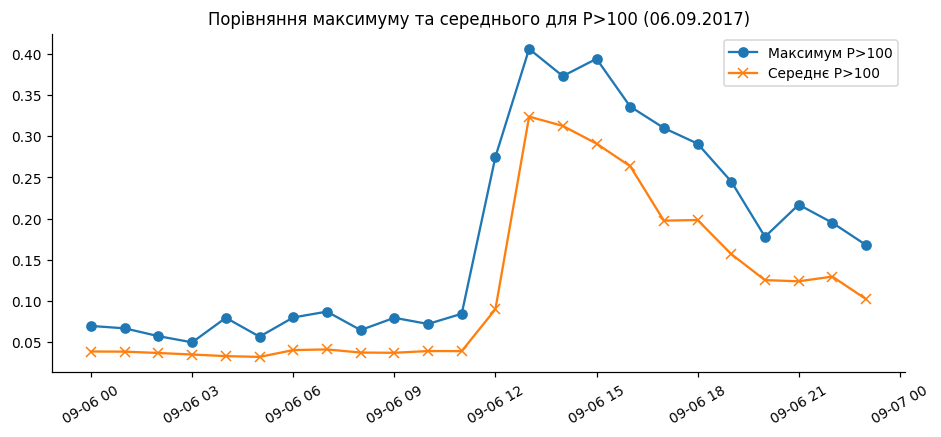

In [15]:
day_data = A_hourly[(A_hourly['ts'] >= '2017-09-06') & (A_hourly['ts'] < '2017-09-07')]
#p>100 максимум і середнє
plt.figure(figsize=(10, 4))
plt.plot(day_data['ts'], day_data['P>100_max'], label='Максимум P>100', marker='o')
plt.plot(day_data['ts'], day_data['P>100_mean'], label='Середнє P>100', marker='x')
plt.title('Порівняння максимуму та середнього для P>100 (06.09.2017)')
plt.xticks(rotation=30)
plt.legend()
plt.show()

**Відповідь 4.2:** *(оскільки я обрав методи max та mean, крива max завжди буде вище або дорівнювати кривій mean. Суттєво графіки будуть відрізнятись тоді, коли буде незвичайно високе значення max(в певних проміжках хвилин було аномально велике значення), тоді max буде високо, а mean згладить це значення)*

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
A_hourly['date'] = A_hourly['ts'].dt.date
C['date'] = C['ts'].dt.date
B['date'] = B['ts'].dt.date

M = A_hourly.merge(C[['ts', 'SPEED', 'DENSITY']], on='ts', how='inner')
M['date'] = M['ts'].dt.date
M = M.merge(B[['date', 'Radio Flux 10.7']], on='date', how='inner')
M = M.drop(columns=['date']).sort_values('ts').reset_index(drop=True)

print("Розмір M:", M.shape)
display(M[M.isna().any(axis=1)])

Розмір M: (600, 20)


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,SPEED,DENSITY,Radio Flux 10.7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140.0
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140.0
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140.0
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140.0
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140.0
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140.0
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140.0
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140.0


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*: 601 outer, 600 inner. Я обрав inner, щоб всі рядки були узгоджені(значення для певної години були у кожній таблиці). відрізняються таблиці для inner та outer лише на один рядок (запис 2017-09-22 00:00:00 є тільки в таблиці C).

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [17]:
M['група'] = None

M.loc[M['P>10_max'] < 10, 'група'] = 'тиха'
M.loc[(M['P>10_max'] >= 10) & (M['P>10_max'] < 1000), 'група'] = 'активна'
M.loc[M['P>10_max'] >= 1000, 'група'] = 'дуже активна'

print(M['група'].value_counts())

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє значення потоку P>100: 1.65862
Медіана потоку P>100: 0.03949


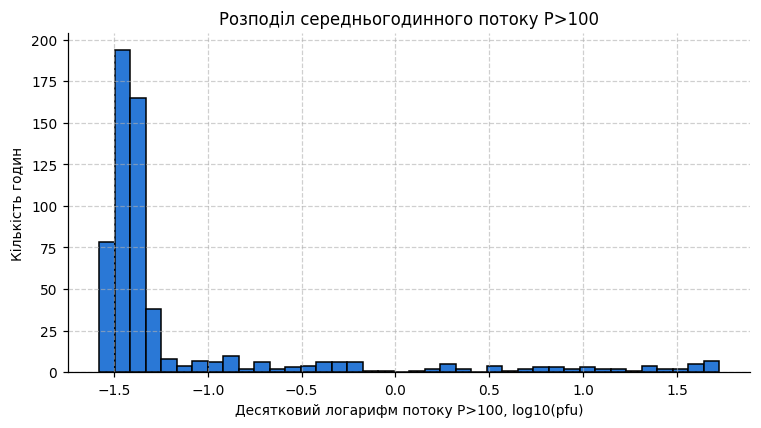

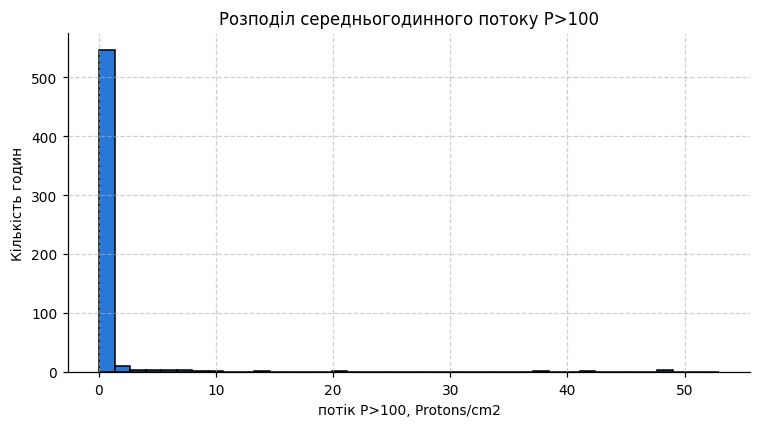

In [19]:
середнє = M['P>100_mean'].mean()
медіана = M['P>100_mean'].median()

print(f"Середнє значення потоку P>100: {середнє:.5f}")
print(f"Медіана потоку P>100: {медіана:.5f}")

дані_для_логарифма = M[M['P>100_mean'] > 0]['P>100_mean']

plt.figure(figsize=(8, 4))
plt.hist(np.log10(дані_для_логарифма), bins=40, color='#2a78d6', edgecolor='black')

plt.title('Розподіл середньогодинного потоку P>100')
plt.xlabel('Десятковий логарифм потоку P>100, log10(pfu)')
plt.ylabel('Кількість годин')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(дані_для_логарифма, bins=40, color='#2a78d6', edgecolor='black')

plt.title('Розподіл середньогодинного потоку P>100')
plt.xlabel('потік P>100, Protons/cm2')
plt.ylabel('Кількість годин')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Висновок(чому середнє й медіана так сильно відрізняються?):** Для гістограми без логарифму ми не дуже можемо щось побачити, найбільше скупчення значень біля значення потоку 0, а  тому ми застосовуємо логарифм. Найбільше значення для потоку ми бачимо 1.4583, 10^(-1.4583) = 0.03480967752.
Те, що середнє та медіана так відрізняються, свідчить про те, що у вибірці є дуже різкі всплески значень, які кардинально збільшують середнє значення, проте не впливають на медіану

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

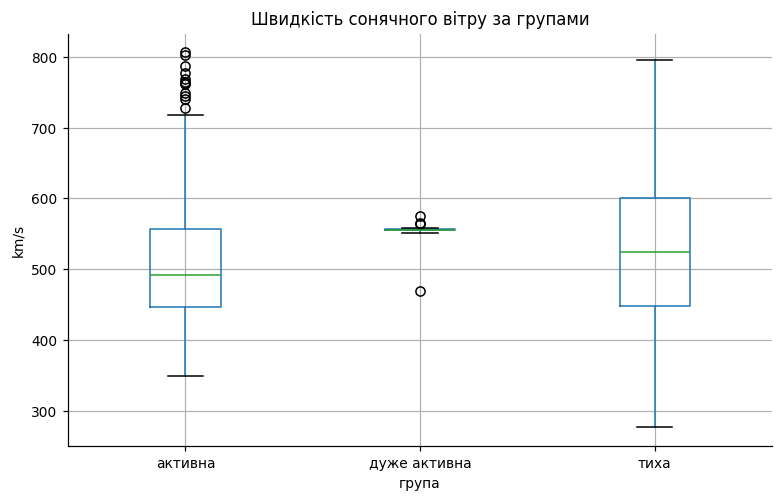

In [20]:
M.boxplot(column='SPEED', by='група', figsize=(8, 5))
plt.title('Швидкість сонячного вітру за групами')
plt.suptitle('') 
plt.ylabel('km/s')
plt.show()

**Висновок:**як ми бачимо по графіку, група тиха має великий проміжок не аномальних значень від 300 км/с до 800 км/с, хоча половина значень вибірки знаходяться навколо медіани. у дуже активної групи дуже малий діапазон значень. це свідчить про те, що або вибірка мала, або значення стабільні. у активної групи багато аномальних значень, що означає короткочасні всплески швидкості вітру. різниця між медіанами для кожної з груп лежить приблизно в межах 60 км/с, що означає, що швидкість по групах не відрізняється дуже сильно.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

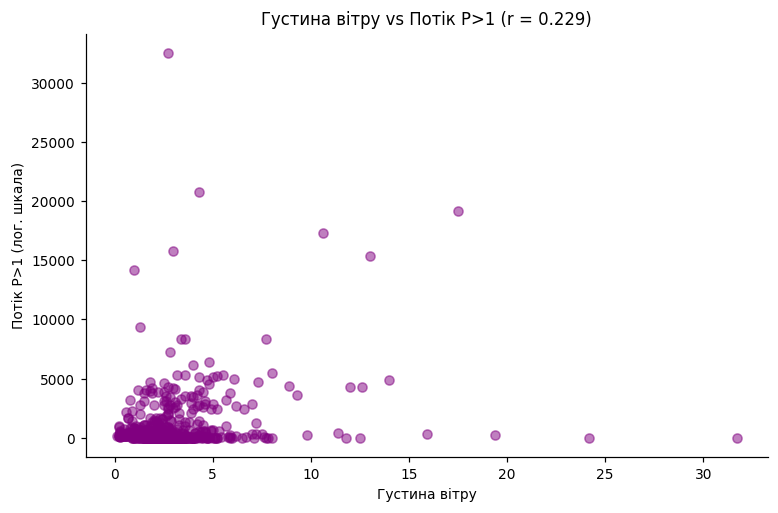

In [21]:
valid = M.dropna(subset=['DENSITY', 'P>1_max'])
correlation = valid['DENSITY'].corr(valid['P>1_max'])

plt.figure(figsize=(8, 5))
plt.scatter(M['DENSITY'], M['P>1_max'], alpha=0.5, color='purple')
plt.title(f'Густина вітру vs Потік P>1 (r = {correlation:.3f})')
plt.xlabel('Густина вітру')
plt.ylabel('Потік P>1 (лог. шкала)')
plt.show()

**Висновок:**Змінні 'густина вітру' та потік P>1 не пов'язані, на графіку кореляції ми не бачимо якогось видимого зв'язку, до того ж коефіцієнт кореляції = 0.229, що означає, що зв'язку немає.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

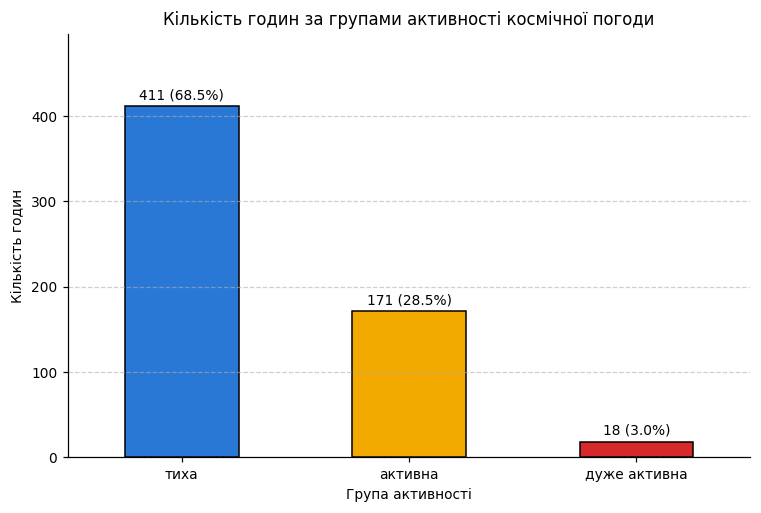

In [22]:
plt.figure(figsize=(8, 5))

кількість = M['група'].value_counts()
загалом = кількість.sum() 

ax = кількість.plot(
    kind='bar', 
    color=['#2a78d6', '#f2a900', '#d62a2a'], 
    edgecolor='black'
)

підписи = [f'{val} ({val/загалом*100:.1f}%)' for val in кількість]

ax.bar_label(ax.containers[0], labels=підписи, padding=3)

plt.title('Кількість годин за групами активності космічної погоди')
plt.xlabel('Група активності')
plt.ylabel('Кількість годин')

plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.ylim(0, ax.get_ylim()[1] * 1.15)

plt.show()

**Висновок:** в групі "тиха" знаходиться більшість годин(68.5% від загальної кількості), в групі "дуже активна" знаходиться найменше значень(3%), в групі "активна" знаходиться 28.5%

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

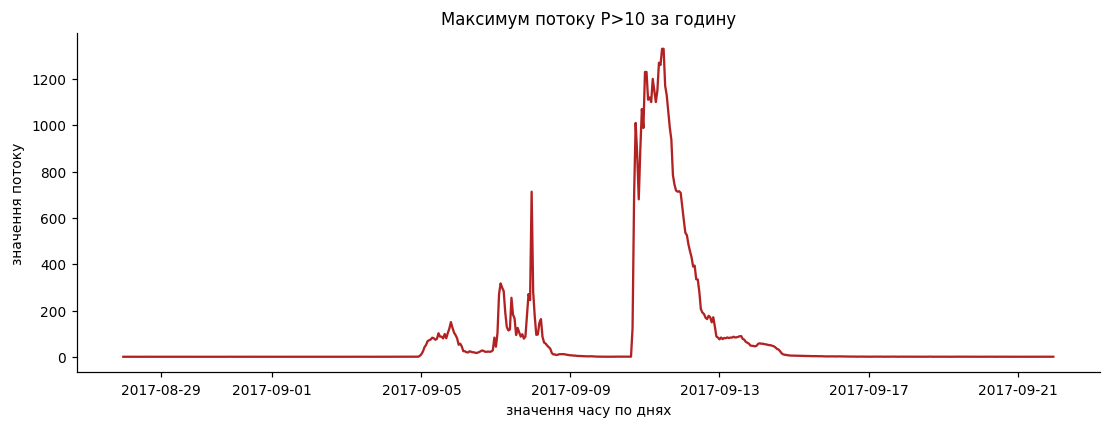

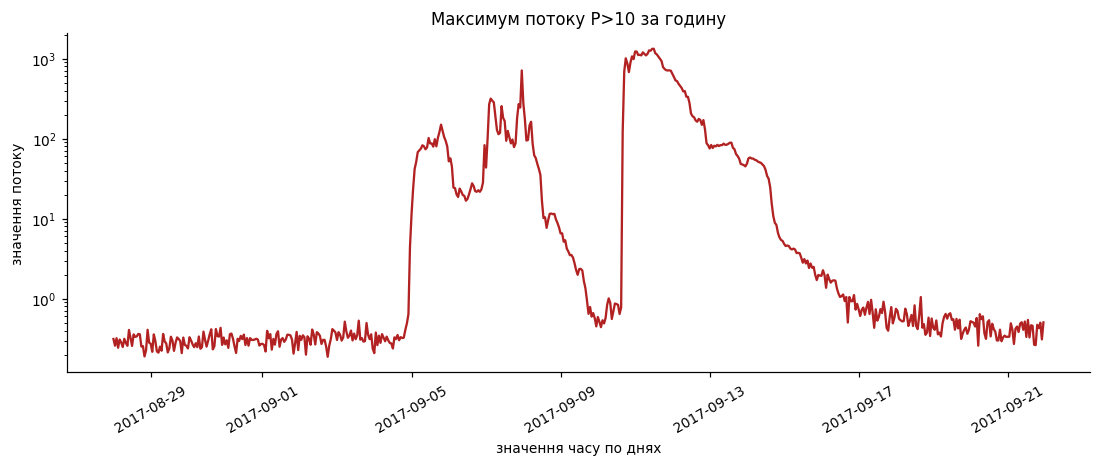

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(M['ts'], M['P>10_max'], color='firebrick')
plt.title('Максимум потоку P>10 за годину')
plt.xlabel('значення часу по днях')
plt.ylabel('значення потоку')

plt.figure(figsize=(12, 4))
plt.plot(M['ts'], M['P>10_max'], color='firebrick')
plt.title('Максимум потоку P>10 за годину')
plt.xlabel('значення часу по днях')
plt.ylabel('значення потоку')
plt.yscale('log')


plt.xticks(rotation=30)
plt.show()

**Висновок:**можемо побачити, що значення в більшості часу було стабільним(<1), проте в деякі моменти були всплески(з 9 по 13 вересня, з 5 по 9 вересня)

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

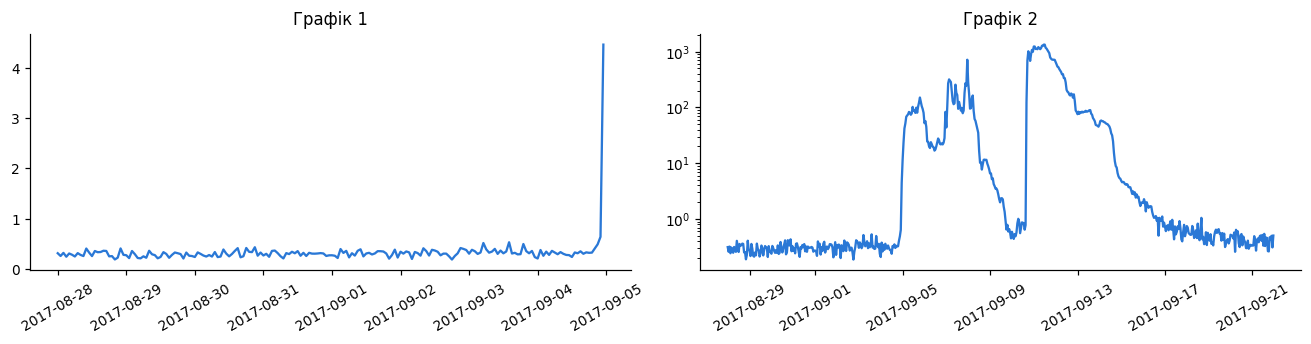

In [24]:
СТОВПЕЦЬ = 'P>10_max'      # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: якшо дивитись тільки на 1 графік, то не дуже можна зрозуміти, що за значення по осі y ми досліджуємо. проте ми бачимо, що по періоду, що ми розглядаємо(28.08 - 05.09) це значення доволі стабільне, проте 05.09 воно різко зростає.
2. Висновок з другого графіка: по другому графіку все ще не зрозуміло, яке значення ми досліджуємо по осі y, проте можна догадатись, що це логарифмічне значення, бо дивимось по степенях 10, на графіку ми можемо побачити всплески значень(з 05.09 по 09.09 та приблизно з 11.09 по 17.09)
3. Дві відмінності між ними: одна з відмінностей - в першому графіку ми беремо вужче значення по датах(28.08 - 05.09), в другому весь період(28.08 - 21.09). Друга відмінність полягає в тому, що в другому графіку ми беремо не просто значення потоку, а беремо з нього логарифм


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

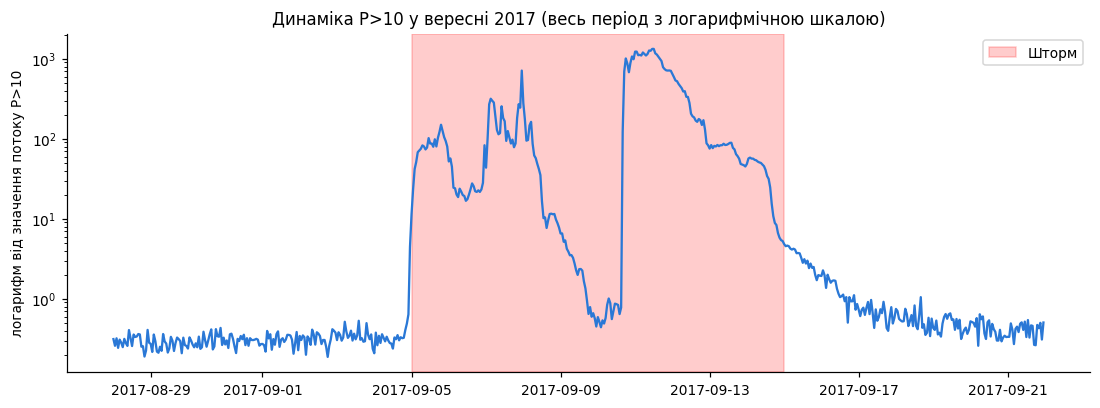

In [25]:
plt.figure(figsize=(12, 4))
plt.plot(M['ts'], M['P>10_max'], color='#2a78d6')
plt.yscale('log')
plt.axvspan('2017-09-05', '2017-09-15', color='red', alpha=0.2, label='Шторм')
plt.title('Динаміка P>10 у вересні 2017 (весь період з логарифмічною шкалою)')
plt.ylabel("логарифм від значення потоку P>10")
plt.legend()
plt.show()

**Відповідь 6.2:** побудував графік саме так, бо він гарно відображає значення по всій вибірці, також червоним прямокутником позначив важливі дані(період шторму), оскільки більшість часу значення були малі та стабільні, і в період з 05.9 по 15.09 сталось різке збільшення та коливання значень.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:**по графіку 5 ми можемо спостерігати, що значення потоку P>10 на всьому проміжку часу доволі стабільне(менше 1), проте в певні періоди(05.09 - 15.09) були аномальні всплески значень(від 1 до 1000)

**Спостереження 2:** по графіку 3 ми можемо зробити висновок, що значення густини вітру та значення потоку p>1 ніяк не пов'язані між собою, про що нам каже графік, а також коефіцієнт кореляції r=0.229.

**Спостереження 3:** по графіку 2 ми можемо побачити, що медіани швидкості для всіх трьох категорій лежать дуже близько одна до одної, приблизно в межах 490–560 км/с. В тихій групі вітер поводить себе найменш передбачувано(діапазон значень від 250 км/с до 800 км/с

### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [26]:
числові_дані = M.select_dtypes(include=['float64', 'int64'])
коеф_варіації = числові_дані.std() / числові_дані.mean()

найбільший_стовпець = коеф_варіації.idxmax()

максимальне_значення = коеф_варіації.max()
#Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?
print(f"Стовпець із найбільшим розкидом: {найбільший_стовпець}")
print(f"Його коефіцієнт варіації: {максимальне_значення:.2f}")

Стовпець із найбільшим розкидом: P>100_mean
Його коефіцієнт варіації: 4.31


**Відповідь 7.2:**ми отримали такий результат, що стовпець із найбільшим розкидом - це P>100_mean. це означає, що поміж стабільного значення протягом всього часу, на певні короткі проміжки часу це значення збільшується в 1000 разів, тому в нього найбільший розкид відносно власного середнього

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [27]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'код, перевірено',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'ні',
    'етапи 6–7, порівняння графіків і спостереження': 'текст, перероблено',
}

ЩО_ПЕРЕВІРЕНО = 'Я уважно перевірив згенерований код на відповідність до мого варіанта (P>100, густина вітру, потік P>1, max). Переконався, що дані завантажуються без заголовків, дати конвертуються правильно за допомогою pd.to_datetime, а об’єднання відбувається по годинах через how="inner". Графіки побудовані логічно з логарифмічними шкалами там, де це потрібно.'

ПІДТВЕРДЖУЮ = True

In [28]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Соснило Богдан
інструменти:                                   Gemini
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    код, перевірено
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                ні
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Я уважно перевірив згенерований код на відповідність до мого варіанта (P>100, густина вітру, потік P>1, max). Переконався, що дані завантажуються без заголовків, дати конвертуються правильно за допомогою pd.to_datetime, а об’єднання відбувається по годинах через how="inner". Графіки побудован

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [29]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 21)


In [30]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
